In [1]:
# Licensed under a 3-clause BSD style license - see LICENSE.rst
"""HAWC Catalog"""

'HAWC Catalog'

# HAWC Catalog Examples

This notebook demonstrates how to use Feupy utilities and Gammapy to interact with the HAWC catalogs (3HWC and 2HWC). You will learn how to:

- Generate flux points for sources in the HAWC catalogs.
- Create spectral energy distribution (SED) plots.
- Inspect flux points tables and metadata.

---


In [2]:
# Import necessary libraries and modules

from gammapy.catalog import SourceCatalog3HWC, SourceCatalog2HWC
from feupy.catalogs.hawc import (
    get_flux_points_3hwc,
    create_flux_points_table_3hwc,
    get_flux_points_2hwc,
    create_flux_points_table_2hwc,
)


## 3HWC Catalog Examples

This section demonstrates how to work with the 3HWC catalog:
1. Generate flux points for a specific source.
2. Create and inspect flux points tables.
3. Plot the spectral energy distribution (SED).


INFO:gammapy.estimators.points.core:Inferred format: gadf-sed


Flux Points Metadata (3HWC):
{'source_name': '3HWC J1825-134', 'catalog_name': '3HWC', 'SED_TYPE': 'dnde', 'search_radius': <Quantity 0. deg>, 'spec0_radius': <Quantity 0. deg>, 'reference': 'https://ui.adsabs.harvard.edu/abs/2020arXiv200708582A/abstract', 'sed_type_init': 'dnde'}


<Axes: xlabel='Energy [$\\mathrm{TeV}$]', ylabel='dnde [$\\mathrm{TeV^{-1}\\,s^{-1}\\,cm^{-2}}$]'>

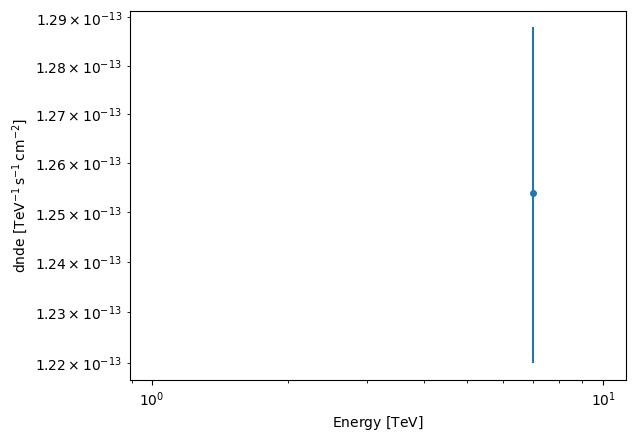

In [3]:
# Load the 3HWC catalog
catalog_3hwc = SourceCatalog3HWC()

# Select a specific source by name
source_3hwc = catalog_3hwc["3HWC J1825-134"]

# Generate FluxPoints for the 3HWC source
flux_points_3hwc = get_flux_points_3hwc(source_3hwc)
print("Flux Points Metadata (3HWC):")
print(flux_points_3hwc.meta)

# Plot the spectral energy distribution (SED)
flux_points_3hwc.plot()


In [4]:
# Inspect the catalog metadata
print("3HWC Catalog Metadata:")
print(catalog_3hwc.table.meta)

# Generate a flux points table for the 3HWC source
flux_points_table_3hwc = create_flux_points_table_3hwc(source_3hwc)
print("Flux Points Table (3HWC):")
print(flux_points_table_3hwc)


3HWC Catalog Metadata:
{'catalog_name': '3HWC', 'reference': 'https://ui.adsabs.harvard.edu/abs/2020arXiv200708582A/abstract'}
Flux Points Table (3HWC):
e_ref       dnde         dnde_errn       dnde_errp        dnde_ul     is_ul
 TeV  1 / (TeV s cm2) 1 / (TeV s cm2) 1 / (TeV s cm2) 1 / (TeV s cm2)      
----- --------------- --------------- --------------- --------------- -----
    7        1.25e-13        3.41e-15        3.39e-15             nan False


## 2HWC Catalog Examples

This section demonstrates how to work with the 2HWC catalog:
1. Generate flux points and tables for a specific source using point and extended models.
2. Handle errors when the extended model is unavailable.
3. Plot the spectral energy distribution (SED).


In [5]:
# Load the 2HWC catalog
catalog_2hwc = SourceCatalog2HWC()

# Select a specific source by name
source_2hwc = catalog_2hwc["2HWC J1825-134"]

# Generate a flux points table for the 2HWC source (default 'point' model)
table_point_2hwc = create_flux_points_table_2hwc(source_2hwc)
print("Flux Points Table (2HWC, Point Model):")
print(table_point_2hwc)

# Generate a flux points table using the 'extended' model (if available)
try:
    table_extended_2hwc = create_flux_points_table_2hwc(source_2hwc, which="extended")
    print("Flux Points Table (2HWC, Extended Model):")
    print(table_extended_2hwc)
except ValueError as error:
    print(f"Extended Model Error (2HWC): {error}")


Flux Points Table (2HWC, Point Model):
e_ref       dnde          dnde_err    dnde_ul is_ul
 TeV  1 / (TeV s cm2) 1 / (TeV s cm2)              
----- --------------- --------------- ------- -----
7.000       1.380e-13       8.166e-15     nan False
Flux Points Table (2HWC, Extended Model):
e_ref       dnde          dnde_err    dnde_ul is_ul
 TeV  1 / (TeV s cm2) 1 / (TeV s cm2)              
----- --------------- --------------- ------- -----
7.000       2.490e-13       1.149e-14     nan False


In [6]:
# Generate a FluxPoints object for the 2HWC source using the point model
flux_points_point_2hwc = get_flux_points_2hwc(source_2hwc)
print("FluxPoints Object (2HWC, Point Model):")
print(flux_points_point_2hwc)

# Generate a FluxPoints object using the extended model (if available)
try:
    flux_points_extended_2hwc = get_flux_points_2hwc(source_2hwc, which="extended")
    print("FluxPoints Object (2HWC, Extended Model):")
    print(flux_points_extended_2hwc)
except ValueError as error:
    print(f"Extended Model Error (2HWC): {error}")


INFO:gammapy.estimators.points.core:Inferred format: gadf-sed
INFO:gammapy.estimators.points.core:Inferred format: gadf-sed


FluxPoints Object (2HWC, Point Model):
FluxPoints
----------

  geom                   : RegionGeom
  axes                   : ['lon', 'lat', 'energy']
  shape                  : (1, 1, 1)
  quantities             : ['norm', 'norm_err', 'norm_ul', 'is_ul']
  ref. model             : pl
  n_sigma                : 1
  n_sigma_ul             : None
  sqrt_ts_threshold_ul   : 2
  sed type init          : dnde

FluxPoints Object (2HWC, Extended Model):
FluxPoints
----------

  geom                   : RegionGeom
  axes                   : ['lon', 'lat', 'energy']
  shape                  : (1, 1, 1)
  quantities             : ['norm', 'norm_err', 'norm_ul', 'is_ul']
  ref. model             : pl
  n_sigma                : 1
  n_sigma_ul             : None
  sqrt_ts_threshold_ul   : 2
  sed type init          : dnde



In [3]:
from feupy.catalogs import SourceCatalogEHWC

In [4]:
SourceCatalogEHWC().table

source_name,ra,ra_err,dec,dec_err,spec_type,Flux_56TeV,Flux_56TeV_err,sqrt_TS_56TeV,sqrt_TS_100 TeV,nearest_2HWC_source,distance_to_2HWC,sed_e_ref,sed_e2dnde,sed_e2dnde_errp,sed_e2dnde_errn,sed_e2dnde_ul,sed_is_ul
,deg,deg,deg,deg,,ph / (s cm2),ph / (s cm2),,,,deg,TeV,TeV / (s cm2),TeV / (s cm2),TeV / (s cm2),TeV / (s cm2),
str14,float64,float64,float64,float64,str4,float64,float64,float64,float64,str9,float64,float64[10],float64[10],float64[10],float64[10],float64[10],float64[10]
eHWC J0534+220,83.61,0.02,22.0,0.03,ecpl,1.200e-14,2e-15,12.0,4.44,J0534+220,0.02,nan .. nan,nan .. nan,nan .. nan,nan .. nan,nan .. nan,nan .. nan
eHWC J1909-193,272.46,0.13,-19.34,0.14,ecpl,2.400e-14,5e-15,6.97,4.82,J1809-190,0.03,nan .. nan,nan .. nan,nan .. nan,nan .. nan,nan .. nan,nan .. nan
eHWC J1825-134,276.4,0.06,-13.37,0.1,ecpl,4.600e-14,5e-15,7.33,7.3,J1825-134,0.07,1.334 .. 236.499,2.410e-11 .. 3.450e-12,5.600e-12 .. 1.250e-12,5.600e-12 .. 1.250e-12,2.410e-11 .. 3.450e-12,0.0 .. 0.0
eHWC J1839-057,279.77,0.12,-5.71,0.11,ecpl,1.500e-14,3e-15,7.03,6.06,J1837-065,0.96,nan .. nan,nan .. nan,nan .. nan,nan .. nan,nan .. nan,nan .. nan
eHWC J1842-035,280.72,0.15,-3.15,0.15,ecpl,1.100e-14,3e-15,6.63,2.7,J1849-001,0.44,nan .. nan,nan .. nan,nan .. nan,nan .. nan,nan .. nan,nan .. nan
eHWC J1850+001,282.59,0.21,0.14,0.12,ecpl,1.300e-14,2e-15,6.63,3.04,J1849-001,0.2,nan .. nan,nan .. nan,nan .. nan,nan .. nan,nan .. nan,nan .. nan
eHWC J1907+063,286.91,0.1,6.3,0.12,lp,2.800e-14,4e-15,8.04,7.3,J1908+063,0.16,1.334 .. 236.499,1.590e-11 .. 1.250e-12,1.400e-12 .. 6.100e-13,1.400e-12 .. 6.100e-13,1.590e-11 .. 1.250e-12,0.0 .. 0.0
eHWC J2019+368,304.95,0.07,36.36,0.08,ecpl,3.600e-14,4e-15,9.63,4.85,J2019+367,0.02,1.334 .. 236.499,2.210e-12 .. 2.740e-13,7.100e-13 .. nan,7.100e-13 .. nan,2.210e-12 .. 2.740e-13,0.0 .. 1.0


In [7]:
from gammapy.catalog import SourceCatalog4FGL
SourceCatalog4FGL().table

Source_Name,DataRelease,RAJ2000,DEJ2000,GLON,GLAT,Conf_68_SemiMajor,Conf_68_SemiMinor,Conf_68_PosAng,Conf_95_SemiMajor,Conf_95_SemiMinor,Conf_95_PosAng,ROI_num,Extended_Source_Name,Signif_Avg,Pivot_Energy,Flux1000,Unc_Flux1000,Energy_Flux100,Unc_Energy_Flux100,SpectrumType,PL_Flux_Density,Unc_PL_Flux_Density,PL_Index,Unc_PL_Index,LP_Flux_Density,Unc_LP_Flux_Density,LP_Index,Unc_LP_Index,LP_beta,Unc_LP_beta,LP_SigCurv,LP_EPeak,Unc_LP_EPeak,PLEC_Flux_Density,Unc_PLEC_Flux_Density,PLEC_IndexS,Unc_PLEC_IndexS,PLEC_ExpfactorS,Unc_PLEC_ExpfactorS,PLEC_Exp_Index,Unc_PLEC_Exp_Index,PLEC_SigCurv,PLEC_EPeak,Unc_PLEC_EPeak,Npred,Flux_Band,Unc_Flux_Band,nuFnu_Band,Sqrt_TS_Band,Variability_Index,Frac_Variability,Unc_Frac_Variability,Signif_Peak,Flux_Peak,Unc_Flux_Peak,Time_Peak,Peak_Interval,Flux_History,Unc_Flux_History,Sqrt_TS_History,ASSOC_4FGL,ASSOC_FGL,ASSOC_FHL,ASSOC_GAM1,ASSOC_GAM2,ASSOC_GAM3,TEVCAT_FLAG,ASSOC_TEV,CLASS1,CLASS2,ASSOC1,ASSOC2,ASSOC_PROB_BAY,ASSOC_PROB_LR,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,Flags
,,deg,deg,deg,deg,deg,deg,deg,deg,deg,deg,,,,MeV,1 / (s cm2),1 / (s cm2),erg / (s cm2),erg / (s cm2),,1 / (MeV s cm2),1 / (MeV s cm2),,,1 / (MeV s cm2),1 / (MeV s cm2),,,,,,MeV,MeV,1 / (MeV s cm2),1 / (MeV s cm2),,,,,,,,MeV,MeV,,1 / (s cm2),1 / (s cm2),erg / (s cm2),,,,,,1 / (s cm2),1 / (s cm2),s,s,1 / (s cm2),1 / (s cm2),,,,,,,,,,,,,,,,deg,deg,deg,
bytes18,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,bytes18,float32,float32,float32,float32,float32,float32,bytes17,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32[8],"float32[8,2]",float32[8],float32[8],float32,float32,float32,float32,float32,float32,float64,float32,float32[14],"float32[14,2]",float32[14],bytes18,bytes18,bytes18,bytes18,bytes18,bytes18,bytes1,bytes30,bytes5,bytes10,bytes28,bytes28,float32,float32,float64,float64,float32,int16
4FGL J0000.3-7355,1,0.0983,-73.9220,307.7090,-42.7295,0.0324,0.0315,-62.700,0.0525,0.0510,-62.700,1726,--,8.493,1917.72,1.4796e-10,2.1770e-11,1.7352e-12,2.6915e-13,PowerLaw,4.2844e-14,6.2686e-15,2.2474,0.1174,4.8417e-14,8.4813e-15,2.1280,0.1969,0.1100,0.1119,1.118,1071.71,1443.50,4.8620e-14,8.0372e-15,2.0489,0.2070,0.18232,0.15102,0.6667,--,1.329,1427.56,2230.54,411.91,2.0565643e-08 .. 5.1613483e-17,-1.6676287e-08 .. 2.0635616e-12,3.2624888e-12 .. 8.333941e-18,1.1720686 .. 0.0,12.8350,0.0000,10.0000,-inf,-inf,-inf,-inf,-inf,6.084946e-12 .. 3.1096483e-09,-- .. 1.5917939e-09,0.0 .. 2.4133372,4FGL J0000.3-7355,--,--,--,--,--,N,--,--,--,--,--,0.0000,0.0000,--,--,--,0
4FGL J0000.5+0743,2,0.1375,7.7273,101.6565,-53.0295,0.0945,0.0700,-10.220,0.1533,0.1135,-10.220,106,--,5.681,1379.88,1.5541e-10,3.0373e-11,1.9306e-12,3.7501e-13,PowerLaw,9.7825e-14,1.8354e-14,2.3308,0.1310,1.1449e-13,2.4667e-14,2.2470,0.1913,0.1097,0.1065,1.194,447.47,737.20,1.0522e-13,2.1944e-14,2.2473,0.1789,0.06567,0.10380,0.6667,--,0.000,--,--,384.92,3.750181e-12 .. 9.930329e-16,-- .. 2.7929685e-12,5.929706e-16 .. 1.554265e-16,0.0 .. 0.0,25.5690,0.5617,0.2739,-inf,-inf,-inf,-inf,-inf,1.5356434e-09 .. 2.4428466e-09,-1.1904873e-09 .. 2.4088174e-09,1.4323782 .. 1.2026387,4FGL J0000.5+0743,--,--,--,--,--,N,--,--,--,--,--,0.0000,0.0000,--,--,--,0
4FGL J0000.7+2530,3,0.1878,25.5153,108.7751,-35.9592,0.0514,0.0410,82.400,0.0833,0.0665,82.400,1344,--,4.197,5989.26,6.7792e-11,2.2785e-11,8.0505e-13,2.4709e-13,PowerLaw,2.1343e-15,6.5433e-16,1.8562,0.1934,3.0265e-15,1.0188e-15,1.8019,0.3299,0.2511,0.1814,1.689,8885.66,6262.71,3.3732e-15,1.1067e-15,1.6250,0.3854,0.68800,0.40956,0.6667,--,1.791,9534.83,4121.65,95.18,5.159399e-14 .. 9.303994e-14,-- .. 3.4502763e-12,8.312768e-18 .. 1.7575507e-14,0.0 .. 0.016723227,13.1493,0.0000,10.0000,-inf,-inf,-inf,-inf,-inf,1.3094809e-09 .. 5.0288596e-10,-6.474343e-10 .. 7.7705853e-10,3.7604396 .. 0.990755,4FGL J0000.7+2530,--,--,--,--,--,N,-